In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import fetch_openml

from xai_aux import CFCalculations
from xai_aux import simulate_noise_effect

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
german_credit = fetch_openml("credit-g", version=1, as_frame=True)
df = german_credit.frame
cat_feat = df.select_dtypes(include=["category", "object"]).columns.tolist()[:-1] # exlcude the target column
num_feat = df.select_dtypes(include=["number"]).columns.tolist()

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['class'])

df = df[cat_feat + num_feat]
df.replace({"none":"no"},inplace=True)

/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_50659/3551743275.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace({"none":"no"},inplace=True)


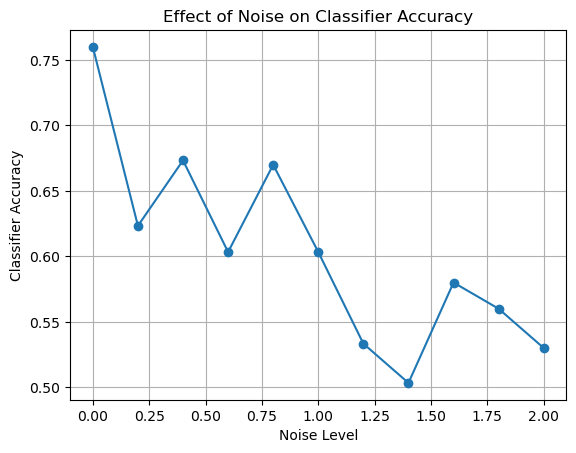

In [4]:
results, datasets = simulate_noise_effect(df, num_feat, cat_feat, y, max_noise=2., step=0.2, min_frequency=None)
noise_levels, accuracies = zip(*results)
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel('Noise Level')
plt.ylabel('Classifier Accuracy')
plt.title('Effect of Noise on Classifier Accuracy')
plt.grid()
plt.show()

In [5]:
n_features = len(df.columns)

In [6]:
def get_polytopes(enc):
    # Get transformed feature names
    feature_names = enc.get_feature_names_out()
    #print("Encoded Feature Names:", feature_names)  # Debugging step

    # Extract number of features per original category
    feature_counts = []
    current_feature = None
    count = 0

    for feature in feature_names:
        original_category = feature.split("_")[0]  # Extract the original category index
        if original_category != current_feature:
            if count > 0:  # Append count for previous category
                feature_counts.append(count)
            current_feature = original_category
            count = 1  # Start counting for new category
        else:
            count += 1
    feature_counts.append(count)  # Append the last count

    # Generate list of lists with sequential numbering
    start = 1
    polytopes = []

    for count in feature_counts:
        polytopes.append(list(range(start, start + count)))
        start += count
    polytopes = [p for p in polytopes if len(p)>1]
    #print("Final polytopes:", polytopes)
    return polytopes

In [7]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X.values, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)
    
    cat_feat2 = [str(i) for i in range(len(cat_feat))]
    enc = OneHotEncoder(drop='first', min_frequency=None, sparse_output=False)
    enc.fit(df_train[cat_feat2])
    X_enc = pd.DataFrame(np.hstack([np.ones((len(df_train),1)), enc.transform(df_train[cat_feat2])]))
    polytopes = get_polytopes(enc)
    
    # # ommitted variables change
    # df_train = df_train.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # df_test = df_test.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # num_feat = [4,5,6]
    # cat_feat = [0,1,2,3]
    
    # if non_iid:
    #     outlier_indices = np.random.choice(len(df_test), n_samples//10, replace=False)
    #     df_test.iloc[outlier_indices, 5:] *= 5
    
    cf_calc = CFCalculations(
        df_train,
        y_train, 
        df_test, 
        y_test,
        [int(i) for i in range(len(cat_feat))],
        [int(i) for i in range(len(cat_feat),len(num_feat)+len(cat_feat))],
        polytopes, 
        do_marg=False,
        min_frequency=None) # no constant assummed
        
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], 
                       columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "cf_calc_mock_data_german_credit.pkl")
    dump(cf_results_dict, "cf_results_dict_german_credit.pkl")
    dump(model_results_dict, "model_results_german_credit.pkl")
    dump(cfs_good_indices, "cfs_good_indices_german_credit.pkl")
    # dump(datasets, "datasets_"+str(mock_data)+"_adult_income.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 74 seconds.


11/11 [==============================] - 0s 638us/step - loss: 0.6142 - accuracy: 0.7303 - precision: 0.7941
TF Test Accuracy: 73.03%
11/11 [==============================] - 0s 518us/step
  Model     Metric     Value
0    lr   accuracy  0.769697
1    lr  precision  0.758851
2   blr   accuracy  0.772727
3   blr  precision  0.762353
4    rf   accuracy  0.760606
5    rf  precision  0.750916
6    tf   accuracy  0.730303
7    tf  precision  0.724060
Working on lr skl
Working on lr blr_mean
Working on lr NICE
Working on lr DiCE


100%|██████████| 330/330 [00:27<00:00, 11.82it/s]


Working on lr RL
features ['x0_0<=X<200' 'x0_<0' 'x0_>=200' 'x0_no checking' 'x1_all paid'
 'x1_critical/other existing credit' 'x1_delayed previously'
 'x1_existing paid' 'x1_no credits/all paid' 'x2_business'
 'x2_domestic appliance' 'x2_education' 'x2_furniture/equipment'
 'x2_new car' 'x2_other' 'x2_radio/tv' 'x2_repairs' 'x2_retraining'
 'x2_used car' 'x3_100<=X<500' 'x3_500<=X<1000' 'x3_<100' 'x3_>=1000'
 'x3_no known savings' 'x4_1<=X<4' 'x4_4<=X<7' 'x4_<1' 'x4_>=7'
 'x4_unemployed' 'x5_female div/dep/mar' 'x5_male div/sep'
 'x5_male mar/wid' 'x5_male single' 'x6_co applicant' 'x6_guarantor'
 'x6_no' 'x7_car' 'x7_life insurance' 'x7_no known property'
 'x7_real estate' 'x8_bank' 'x8_no' 'x8_stores' 'x9_for free' 'x9_own'
 'x9_rent' 'x10_high qualif/self emp/mgmt' 'x10_skilled'
 'x10_unemp/unskilled non res' 'x10_unskilled resident' 'x11_no' 'x11_yes'
 'x12_no' 'x12_yes']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] [13, 14, 15, 16, 17, 18, 19]
{0: ['0<=X<200', '<0', '>=200', 'no c

100%|██████████| 4/4 [00:00<00:00, 32.48it/s]


Working on rf NICE
Working on rf DiCE


100%|██████████| 330/330 [00:21<00:00, 15.25it/s]


Working on rf RL
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] [13, 14, 15, 16, 17, 18, 19]
{0: ['0<=X<200', '<0', '>=200', 'no checking'], 1: ['all paid', 'critical/other existing credit', 'delayed previously', 'existing paid', 'no credits/all paid'], 2: ['business', 'domestic appliance', 'education', 'furniture/equipment', 'new car', 'other', 'radio/tv', 'repairs', 'retraining', 'used car'], 3: ['100<=X<500', '500<=X<1000', '<100', '>=1000', 'no known savings'], 4: ['1<=X<4', '4<=X<7', '<1', '>=7', 'unemployed'], 5: ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single'], 6: ['co applicant', 'guarantor', 'no'], 7: ['car', 'life insurance', 'no known property', 'real estate'], 8: ['bank', 'no', 'stores'], 9: ['for free', 'own', 'rent'], 10: ['high qualif/self emp/mgmt', 'skilled', 'unemp/unskilled non res', 'unskilled resident'], 11: ['no', 'yes'], 12: ['no', 'yes']}


 10%|▉         | 951/10000 [00:26<04:02, 37.29it/s]

In [ ]:
df_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
521,<0,existing paid,radio/tv,<100,1<=X<4,female div/dep/mar,no,real estate,no,own,skilled,no,yes,18.0,3190.0,2.0,2.0,24.0,1.0,1.0
737,<0,existing paid,new car,100<=X<500,1<=X<4,male single,no,car,no,own,unskilled resident,yes,yes,18.0,4380.0,3.0,4.0,35.0,1.0,2.0
740,<0,all paid,new car,100<=X<500,4<=X<7,male single,no,car,bank,own,skilled,no,yes,24.0,2325.0,2.0,3.0,32.0,1.0,1.0
660,>=200,existing paid,radio/tv,<100,1<=X<4,male mar/wid,no,real estate,no,rent,skilled,no,yes,12.0,1297.0,3.0,4.0,23.0,1.0,1.0
411,no checking,critical/other existing credit,used car,<100,4<=X<7,male single,no,car,no,own,high qualif/self emp/mgmt,yes,yes,33.0,7253.0,3.0,2.0,35.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,>=200,critical/other existing credit,used car,500<=X<1000,1<=X<4,male single,no,car,no,own,skilled,yes,yes,15.0,2360.0,2.0,2.0,36.0,1.0,1.0
342,0<=X<200,existing paid,radio/tv,500<=X<1000,<1,male mar/wid,no,real estate,no,rent,skilled,no,yes,18.0,3213.0,1.0,3.0,25.0,1.0,1.0
485,0<=X<200,delayed previously,new car,<100,unemployed,male single,no,life insurance,no,own,high qualif/self emp/mgmt,yes,yes,6.0,1209.0,4.0,4.0,47.0,1.0,1.0
711,<0,all paid,education,<100,>=7,female div/dep/mar,no,no known property,no,for free,skilled,no,yes,6.0,1198.0,4.0,4.0,35.0,1.0,1.0
